# Heart Disease Risk Prediction Using Decision Tree-Based Healthcare Analytics
## Phase 3: Comprehensive Exploratory Data Analysis (EDA)

**Project Objective:** Perform rigorous exploratory healthcare analytics on the Cleveland Heart Disease dataset (`data/processed/heart_disease_processed.csv`) to characterize patient demographics, vital sign profiles, clinical symptoms, and feature associations with heart disease diagnosis.

---

### Notebook Structure:
1. **Import Libraries & Setup Styling**
2. **Load Processed Dataset**
3. **Dataset Overview & Schema Inspection**
4. **Data Quality & Integrity Verification**
5. **Descriptive & Stratified Statistics**
6. **Target Variable Analysis**
7. **Demographic Analysis (Age & Sex)**
8. **Vital Signs Analysis (Blood Pressure, Cholesterol, Heart Rate)**
9. **Clinical & Exercise Stress Analysis (Chest Pain, Angina, ST Depression, Vessels, Thalassemia)**
10. **Correlation Analysis & Heatmap**
11. **Outlier Analysis (IQR Method & Clinical Assessment)**
12. **Key Healthcare Analytics Insights**
13. **EDA Summary & Next Steps**

### 1. Import Libraries & Setup Styling

In [1]:
import sys
from pathlib import Path

# Ensure project root is in sys.path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_preprocessing import get_processed_data_path, get_feature_types, TARGET_COLUMN
from src.exploratory_analysis import set_plot_theme, compute_summary_statistics, generate_all_eda_figures

set_plot_theme()
%matplotlib inline

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. Load Processed Dataset

In [2]:
data_path = get_processed_data_path()
df = pd.read_csv(data_path)
print(f"Loaded processed dataset from: {data_path}")
print(f"Shape: {df.shape[0]} records, {df.shape[1]} attributes")

Loaded processed dataset from: D:\Sem_Project\heart-disease-risk-classifier\data\processed\heart_disease_processed.csv
Shape: 303 records, 14 attributes


### 3. Dataset Overview & Schema Inspection

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
5,56,1,1,120,236,0,0,178,0,0.8,0,0,1,0
6,62,0,3,140,268,0,2,160,0,3.6,2,2,1,1
7,57,0,3,120,354,0,0,163,1,0.6,0,0,1,0
8,63,1,3,130,254,0,2,147,0,1.4,1,1,3,1
9,53,1,3,140,203,1,2,155,1,3.1,2,0,3,1


### 4. Data Quality & Integrity Verification

In [5]:
print("Missing values per attribute:")
print(df.isnull().sum())
print(f"\nExact duplicate rows: {df.duplicated().sum()}")
print(f"Target unique values: {df['target'].unique()}")

Missing values per attribute:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Exact duplicate rows: 0
Target unique values: [0 1]


### 5. Descriptive & Stratified Statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,2.158416,0.960126,0.0,2.0,2.0,3.0,3.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [7]:
summary_stats = compute_summary_statistics(df)
print("Numerical Feature Means Stratified by Target Class:")
for feat, val in summary_stats["numerical_statistics"].items():
    mean_0 = val["by_target"][0]["mean"]
    mean_1 = val["by_target"][1]["mean"]
    print(f"  {feat:10s} | No Disease (0): {mean_0:7.2f} | Heart Disease (1): {mean_1:7.2f} | Diff: {mean_1 - mean_0:+.2f}")

Numerical Feature Means Stratified by Target Class:
  age        | No Disease (0):   52.59 | Heart Disease (1):   56.63 | Diff: +4.04
  trestbps   | No Disease (0):  129.25 | Heart Disease (1):  134.57 | Diff: +5.32
  chol       | No Disease (0):  242.64 | Heart Disease (1):  251.47 | Diff: +8.83
  thalach    | No Disease (0):  158.38 | Heart Disease (1):  139.26 | Diff: -19.12
  oldpeak    | No Disease (0):    0.59 | Heart Disease (1):    1.57 | Diff: +0.99


### 6. Target Variable Analysis

The target variable indicates the presence ($1$) or absence ($0$) of heart disease.

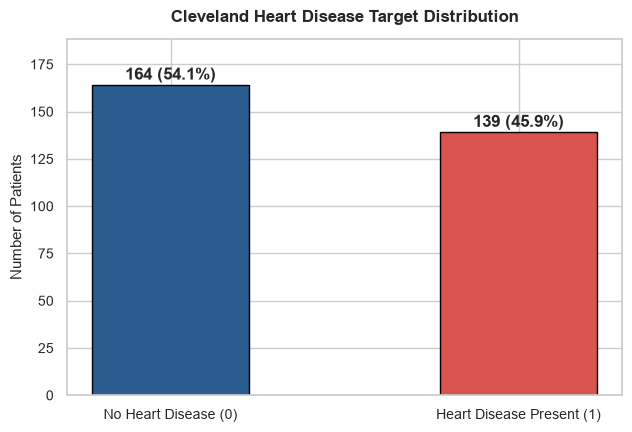

In [8]:
target_counts = df['target'].value_counts().sort_index()
target_pcts = df['target'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(['No Heart Disease (0)', 'Heart Disease Present (1)'], target_counts.values, color=['#2b5c8f', '#d9534f'], width=0.45, edgecolor='black')
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{int(h)} ({h/len(df)*100:.1f}%)", xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 4), textcoords="offset points", ha="center", fontweight="bold")
ax.set_title("Cleveland Heart Disease Target Distribution", pad=12, fontweight="bold")
ax.set_ylabel("Number of Patients")
ax.set_ylim(0, max(target_counts) * 1.15)
plt.show()

### 7. Demographic Analysis: Age & Biological Sex

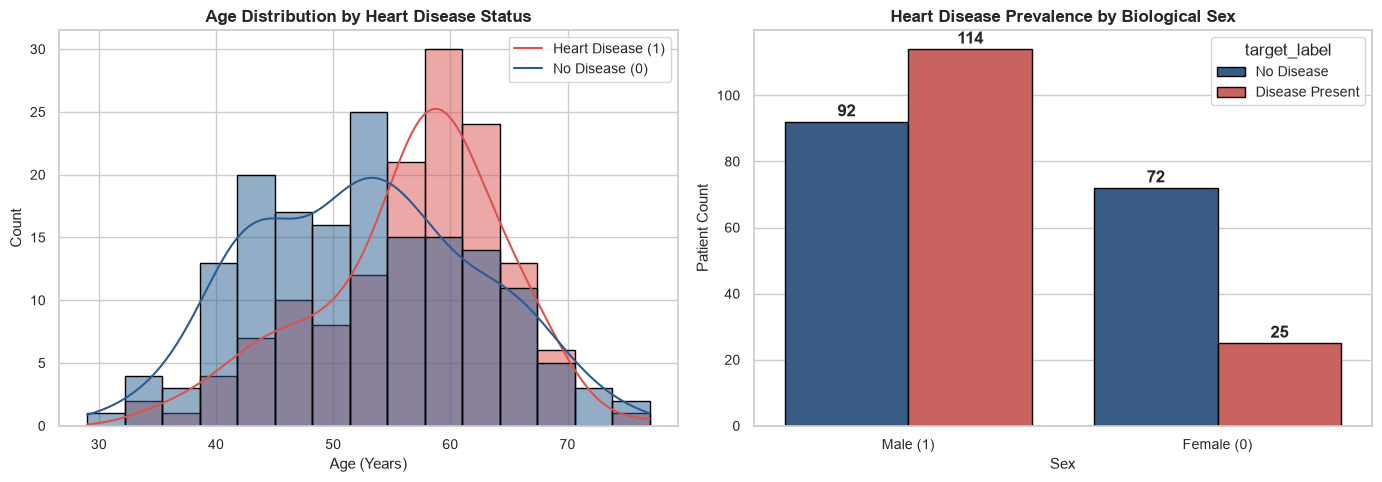

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Distribution by Target
sns.histplot(data=df, x='age', hue='target', kde=True, palette={0: '#2b5c8f', 1: '#d9534f'}, bins=15, ax=axes[0], edgecolor='black')
axes[0].set_title("Age Distribution by Heart Disease Status", fontweight="bold")
axes[0].set_xlabel("Age (Years)")
axes[0].legend(['Heart Disease (1)', 'No Disease (0)'])

# Heart Disease Prevalence by Sex
df_sex = df.copy()
df_sex['sex_label'] = df_sex['sex'].map({0: 'Female (0)', 1: 'Male (1)'})
df_sex['target_label'] = df_sex['target'].map({0: 'No Disease', 1: 'Disease Present'})
sns.countplot(data=df_sex, x='sex_label', hue='target_label', palette={'No Disease': '#2b5c8f', 'Disease Present': '#d9534f'}, edgecolor='black', ax=axes[1])
for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f"{int(h)}", xy=(p.get_x() + p.get_width()/2, h), xytext=(0, 4), textcoords="offset points", ha="center", fontweight="bold")
axes[1].set_title("Heart Disease Prevalence by Biological Sex", fontweight="bold")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Patient Count")

plt.tight_layout()
plt.show()

### 8. Vital Signs & Laboratory Analysis (Blood Pressure, Cholesterol, Peak Heart Rate)

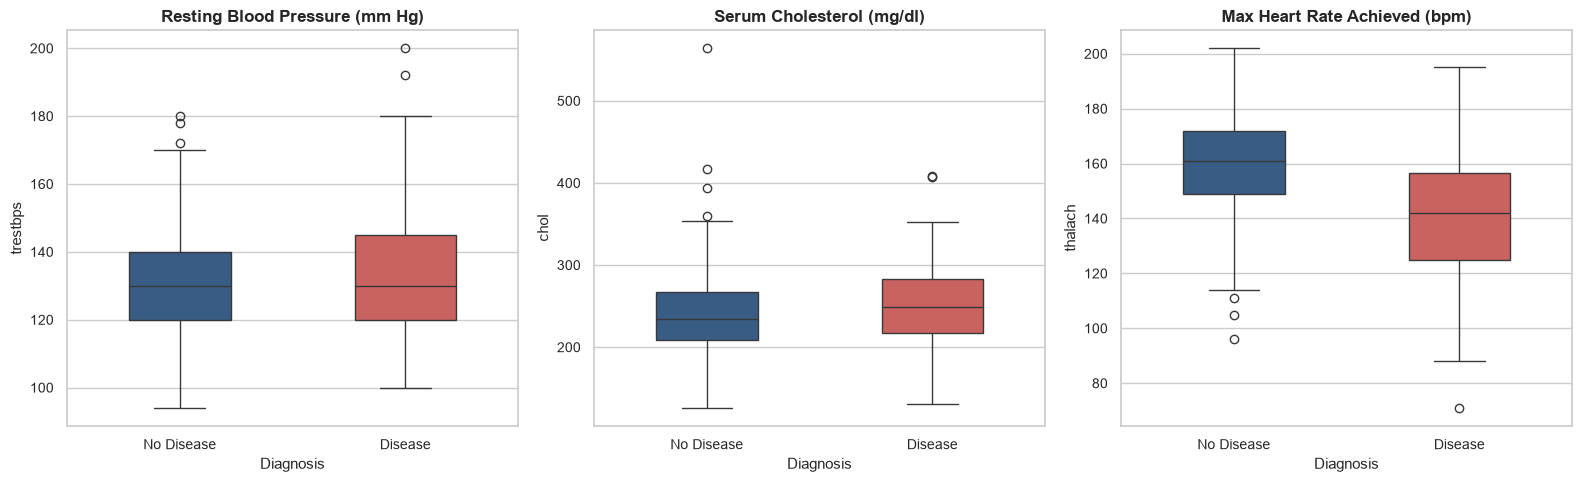

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df_plot = df.copy()
df_plot['target_label'] = df_plot['target'].map({0: 'No Disease', 1: 'Disease'})
pal = {'No Disease': '#2b5c8f', 'Disease': '#d9534f'}

sns.boxplot(data=df_plot, x='target_label', y='trestbps', hue='target_label', palette=pal, legend=False, width=0.45, ax=axes[0])
axes[0].set_title("Resting Blood Pressure (mm Hg)", fontweight="bold")
axes[0].set_xlabel("Diagnosis")

sns.boxplot(data=df_plot, x='target_label', y='chol', hue='target_label', palette=pal, legend=False, width=0.45, ax=axes[1])
axes[1].set_title("Serum Cholesterol (mg/dl)", fontweight="bold")
axes[1].set_xlabel("Diagnosis")

sns.boxplot(data=df_plot, x='target_label', y='thalach', hue='target_label', palette=pal, legend=False, width=0.45, ax=axes[2])
axes[2].set_title("Max Heart Rate Achieved (bpm)", fontweight="bold")
axes[2].set_xlabel("Diagnosis")

plt.tight_layout()
plt.show()

### 9. Clinical & Stress Test Analysis (Chest Pain, Angina, Oldpeak, Vessels, Thalassemia)

2026-08-25 13:30:58,552 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-25 13:30:58,567 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


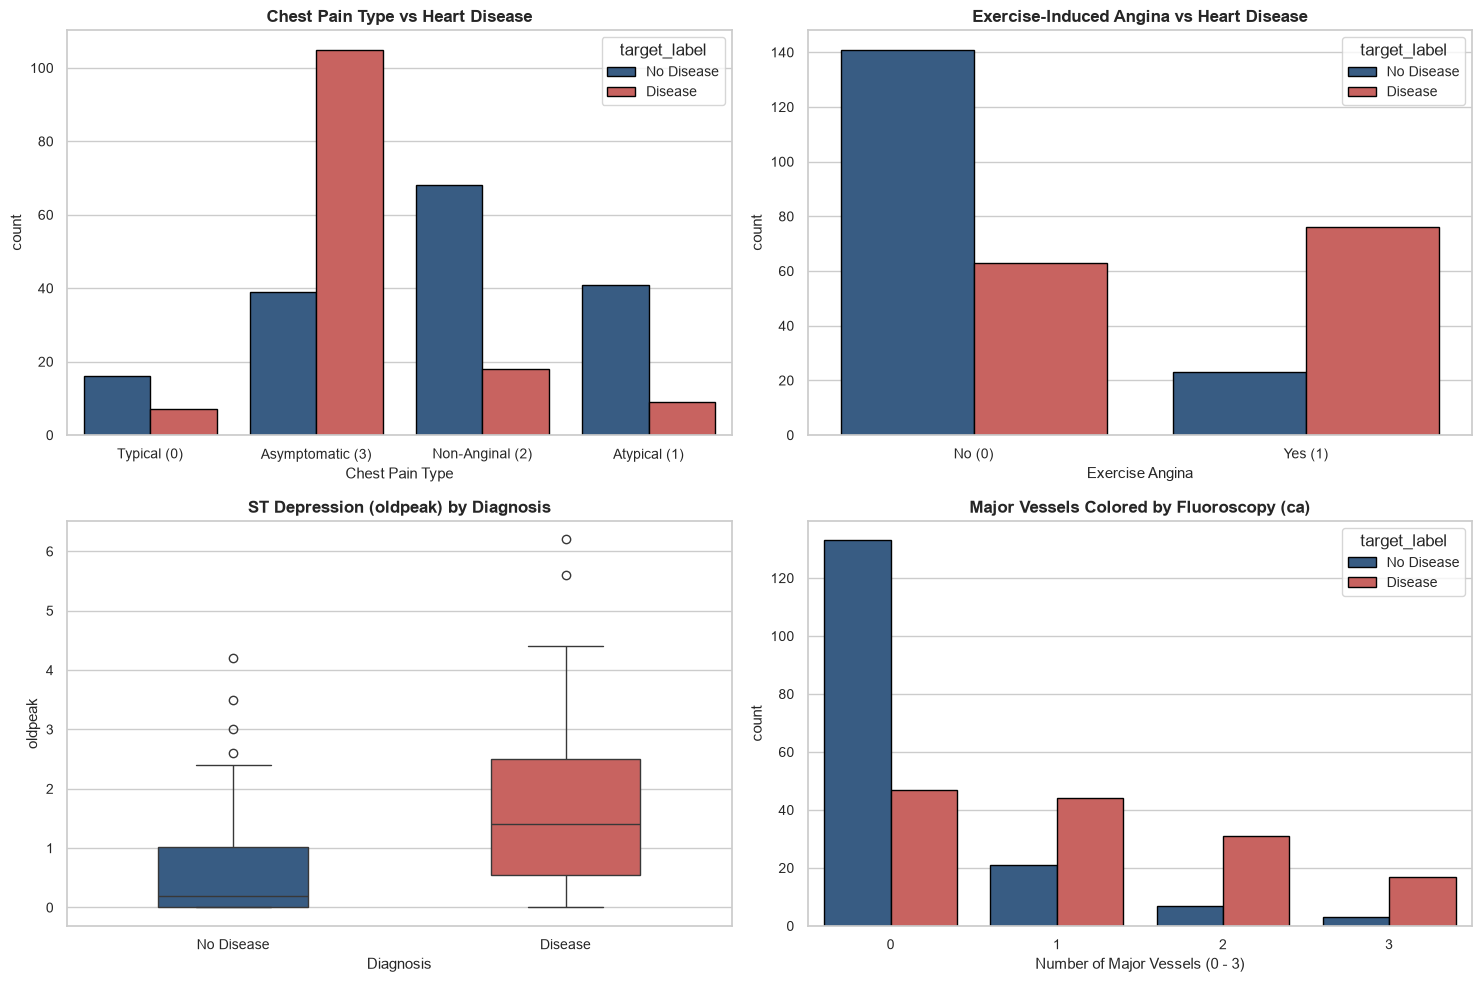

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Chest pain type
df_plot['cp_label'] = df_plot['cp'].map({0: 'Typical (0)', 1: 'Atypical (1)', 2: 'Non-Anginal (2)', 3: 'Asymptomatic (3)'})
sns.countplot(data=df_plot, x='cp_label', hue='target_label', palette=pal, edgecolor='black', ax=axes[0, 0])
axes[0, 0].set_title("Chest Pain Type vs Heart Disease", fontweight="bold")
axes[0, 0].set_xlabel("Chest Pain Type")

# 2. Exercise-induced angina
df_plot['exang_label'] = df_plot['exang'].map({0: 'No (0)', 1: 'Yes (1)'})
sns.countplot(data=df_plot, x='exang_label', hue='target_label', palette=pal, edgecolor='black', ax=axes[0, 1])
axes[0, 1].set_title("Exercise-Induced Angina vs Heart Disease", fontweight="bold")
axes[0, 1].set_xlabel("Exercise Angina")

# 3. ST Depression (oldpeak)
sns.boxplot(data=df_plot, x='target_label', y='oldpeak', hue='target_label', palette=pal, legend=False, width=0.45, ax=axes[1, 0])
axes[1, 0].set_title("ST Depression (oldpeak) by Diagnosis", fontweight="bold")
axes[1, 0].set_xlabel("Diagnosis")

# 4. Major vessels (ca)
df_plot['ca_str'] = df_plot['ca'].astype(str)
sns.countplot(data=df_plot, x='ca_str', hue='target_label', palette=pal, edgecolor='black', order=['0', '1', '2', '3'], ax=axes[1, 1])
axes[1, 1].set_title("Major Vessels Colored by Fluoroscopy (ca)", fontweight="bold")
axes[1, 1].set_xlabel("Number of Major Vessels (0 - 3)")

plt.tight_layout()
plt.show()

### 10. Correlation Analysis

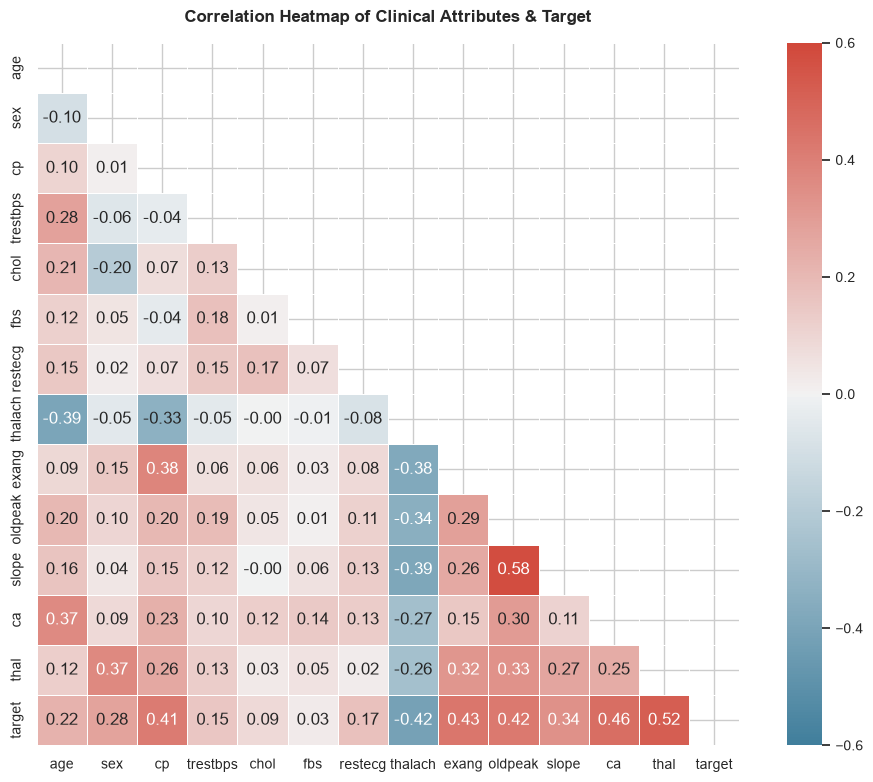

In [12]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(230, 15, as_cmap=True), vmax=0.6, vmin=-0.6, center=0, annot=True, fmt=".2f", square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap of Clinical Attributes & Target", pad=15, fontweight="bold")
plt.show()

In [13]:
print("Linear Correlation with Target Variable (Ranked):")
print(df.corr()['target'].sort_values(ascending=False).round(4))

Linear Correlation with Target Variable (Ranked):
target      1.0000
thal        0.5159
ca          0.4600
exang       0.4319
oldpeak     0.4245
cp          0.4144
slope       0.3392
sex         0.2768
age         0.2231
restecg     0.1692
trestbps    0.1508
chol        0.0852
fbs         0.0253
thalach    -0.4172
Name: target, dtype: float64


### 11. Outlier Analysis (Interquartile Range Method)

In [14]:
for feat, o in summary_stats['outlier_analysis'].items():
    print(f"Feature: {feat:10s} | IQR: {o['iqr']:6.2f} | Bounds: [{o['lower_bound']:6.2f}, {o['upper_bound']:6.2f}] | Outliers: {o['outlier_count']} ({o['outlier_percentage']}%) | Values: {o['outlier_values']}")

Feature: age        | IQR:  13.00 | Bounds: [ 28.50,  80.50] | Outliers: 0 (0.0%) | Values: []
Feature: trestbps   | IQR:  20.00 | Bounds: [ 90.00, 170.00] | Outliers: 9 (2.97%) | Values: [172.0, 180.0, 200.0, 174.0, 178.0, 192.0, 180.0, 178.0, 180.0]
Feature: chol       | IQR:  64.00 | Bounds: [115.00, 371.00] | Outliers: 5 (1.65%) | Values: [417.0, 407.0, 564.0, 394.0, 409.0]
Feature: thalach    | IQR:  32.50 | Bounds: [ 84.75, 214.75] | Outliers: 1 (0.33%) | Values: [71.0]
Feature: oldpeak    | IQR:   1.60 | Bounds: [ -2.40,   4.00] | Outliers: 5 (1.65%) | Values: [6.2, 5.6, 4.2, 4.2, 4.4]


### 12. Key Healthcare Analytics Insights

Based on calculated statistics and analytical visualizations from the Cleveland Heart Disease dataset:

1. **Cohort & Class Balance:** The dataset contains $303$ records with balanced representation: **$164$ ($54.13%$)** without heart disease and **$139$ ($45.87%$)** with heart disease.
2. **Age Profile:** Heart disease patients are slightly older on average ($56.63 \pm 7.94$ years, median $58.0$) compared to non-disease individuals ($52.59 \pm 9.51$ years, median $52.0$).
3. **Biological Sex:** Males demonstrate a higher proportion of heart disease cases ($55.34%$, $114/206$) compared to females ($25.77%$, $25/97$) in this clinical cohort ($r = 0.277$).
4. **Chest Pain Presentation:** Patients with asymptomatic chest pain (`cp=3`) show a $72.92%$ ($105/144$) disease prevalence, representing the most common presentation in referral patients.
5. **Exercise Stress Vitals:**
   - **Maximum Heart Rate (`thalach`):** Shows strong inverse correlation ($r = -0.417$). Disease patients achieved significantly lower peak heart rates ($139.26 \pm 22.59$ bpm vs $158.38 \pm 19.20$ bpm).
   - **Exercise Angina (`exang`):** Positive correlation ($r = 0.432$). Disease prevalence was $76.77%$ with exercise angina vs $30.88%$ without.
   - **ST Depression (`oldpeak`):** Strong positive correlation ($r = 0.425$). Disease patients had elevated ST depression ($1.57 \pm 1.30$ mm vs $0.59 \pm 0.78$ mm).
6. **Fluoroscopy & Thalassemia:**
   - **Major Vessels (`ca`):** Prevalence increases from $26.11%$ ($ca=0$) to $67.69%$ ($ca=1$), $81.58%$ ($ca=2$), and $85.00%$ ($ca=3$) ($r = 0.460$).
   - **Thalassemia (`thal`):** Reversible defect status (`thal=3`) has a $76.07%$ ($89/117$) disease rate ($r = 0.516$).
7. **Outlier Assessment:** All identified IQR outliers (e.g. blood pressure $\ge 172$ mm Hg, cholesterol up to $564$ mg/dl, oldpeak up to $6.2$ mm) reflect physiologically valid, high-risk cardiac pathology and are preserved without artificial deletion.

### 13. EDA Summary & Preparation for Modeling

- All $14$ clinical figures have been generated and saved under `reports/figures/`.
- Features showing strong linear and non-linear predictive associations include `thal`, `ca`, `oldpeak`, `exang`, `cp`, and `thalach`.
- The dataset is fully validated and ready for **Phase 4 — Model Training & Comparison**.